In [26]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [27]:
import xarray as xr
import numpy as np
import xgcm
import matplotlib.pyplot as plt
from load_example_ecco_grid import * 
import xbudget
print("xarray:",  xr.__version__)
print("xgcm:", xgcm.__version__)

xarray: 2025.10.1
xgcm: 0.9.0


In [28]:
def zero_top_layer(ds, varname = "", zdim = "k_l"):
    return xr.where(ds[f"{zdim}"] != ds[f"{zdim}"].isel({f"{zdim}":0}),ds[varname].copy(),0.0,)
def make_flux_3d(ds, varname = "", zdim = "k"):
    k  = ds[f"{zdim}"]
    return xr.where(k == k.isel({f"{zdim}":0}), ds[varname].copy().expand_dims({f"{zdim}":k}),0.0,)

In [41]:
ecco_budget = xr.open_mfdataset("../data/data/ECCO_budget_terms.zarr")
ecco_budget["WVELMASS_interior"] = zero_top_layer(ecco_budget, varname = "WVELMASS", zdim = "k_l")
ecco_budget["oceFWflx_3d"] = make_flux_3d(ecco_budget, varname = "oceFWflx", zdim = "k")
ecco_budget = ecco_budget.chunk({"k_l":-1, "tile":-1, "i_g": -1, "j": -1, "j_g":-1, "i":-1})
ecco_budget = ecco_budget.fillna(0.0)


In [42]:
grid = construct_grid(ecco_budget)
dt = grid._ds["time_bounds"].diff("time_bounds").rename({"time_bounds":"time"})
dt = dt.dt.total_seconds() #nice! 
xbudget_dict = xbudget.load_yaml("ECCOV4r4.yaml").copy()
xbudget.collect_budgets(grid, xbudget_dict)
simple_budgets = xbudget.aggregate(xbudget_dict)
simple_budgets

{'mass': {'lambda': 'density',
  'thickness': 'thkcello',
  'lhs': {},
  'rhs': {'advection': 'mass_rhs_sum_advection',
   'surface_exchange_flux': 'mass_rhs_sum_surface_exchange_flux'}}}

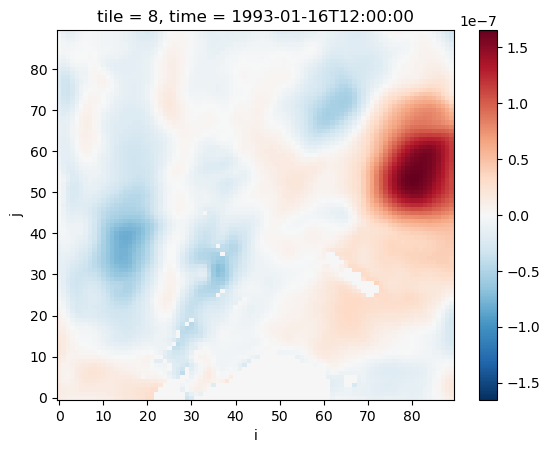

In [43]:
deta_dt = grid._ds["ETAN_bounds"].diff("time_bounds").rename({"time_bounds":"time"}) / dt
deta_dt.coords["time"] = grid._ds["time"]
deta_dt.isel(time = 0, tile = 8).plot()


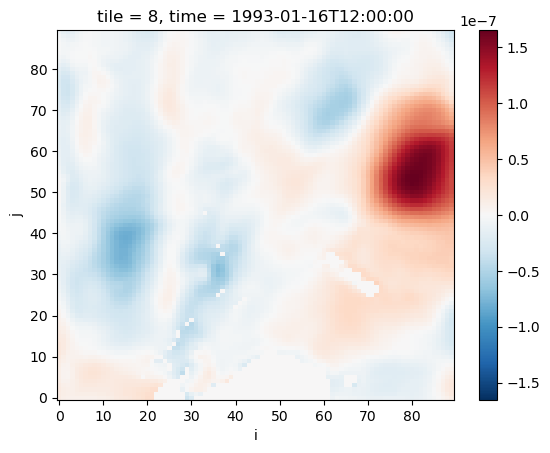

In [44]:
adv_conv = grid._ds[xbudget.get_vars(xbudget_dict, "mass_rhs_sum")['var']]
adv_conv = adv_conv / (adv_conv.rA  * 1029.00)
adv_conv.isel(time = 0, tile = 8).sum("k").plot()

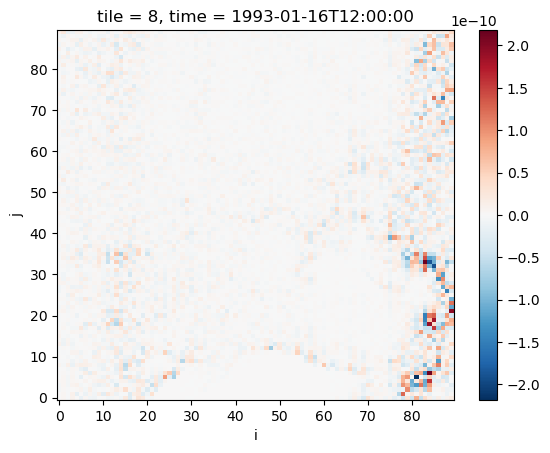

In [45]:
(deta_dt - adv_conv.sum("k")).isel(time = 0, tile = 8).plot()